# Assignment 4 — "Do you AGREE?" — BERT from scratch & Sentence‑BERT (submission)

**Author:** Saugat Shakya (MSc — Natural Language Processing)
**Date:** 2026-02-14

**Notebook structure (sections)**
1. Setup & reproducibility
2. Configuration & hyperparameters
3. Data (BookCorpus subset)
4. Vocabulary & tokenizer
5. Compact BERT implementation + unit tests
6. BERT pretraining (checkpointed)
7. SNLI data loader
8. Sentence‑BERT (siamese)
9. SBERT training (loads pretrained encoder if available)
10. Evaluation & plots
11. Inference & embedding analysis
12. Save artifacts (models, configs, manifest)
13. Sanity checks / unit tests

**References:** Devlin et al. (BERT), Reimers & Gurevych (SBERT), HuggingFace BookCorpus & SNLI datasets.

*See the next cell for quick reproduction instructions.*

## How to reproduce (quick)

- For a fast smoke/test on CPU (verifies correctness): leave `RUN_MODE='test'` (default), restart kernel → Run All. This completes in minutes.
- For a meaningful BERT pretraining and SBERT results use a GPU: set `RUN_MODE='small'` or `'medium'`, restart kernel → Run All. Expect long runs for full pretraining; use `small` first.
- Output (important files):
  - models: `results/main_clean/{RUN_MODE}/models/bert_pretrained.pt` (or `bert_smoke.pt` for test), `sbert_clean.pt`
  - plots: `results/main_clean/{RUN_MODE}/plots/*.png`
  - configs/vocab: `results/main_clean/{RUN_MODE}/configs/word2id.json`
- To reproduce SBERT from a pretrained encoder: ensure a BERT checkpoint exists in `results/.../models/` before running the SBERT training cell.

Tip: web demo is kept separate — the demo loads the models saved under `results/main_clean/{RUN_MODE}/models/`.

In [48]:
# -----------------------------
# 1) Setup & reproducibility
# -----------------------------
import os, re, time
import json
import numpy as np
import random
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device={device} | torch={torch.__version__}")

# results paths (per-run)
RUN_LABEL = 'main_clean'
print_dir = lambda p: os.path.abspath(p)


device=cpu | torch=2.2.2


In [49]:
# -----------------------------
# 2) Configuration & hyperparameters
# -----------------------------
MODES = {
    'test':  { 'dataset':'bookcorpus', 'data_pct':'[:1%]', 'snli_train':5000,  'snli_val':250,  'snli_test':250,  'epochs_bert':2,  'epochs_sbert':20,  'steps_per_epoch':50,  'n_layers':2, 'n_heads':2, 'd_model':128, 'd_ff':512, 'd_k':64, 'description':'fast CPU smoke' },
    'small': { 'dataset':'wikipedia', 'data_pct':'[:5%]', 'snli_train':20000, 'snli_val':500,  'snli_test':500,  'epochs_bert':5, 'epochs_sbert':20, 'steps_per_epoch':500, 'n_layers':4, 'n_heads':4, 'd_model':256, 'd_ff':1024, 'd_k':64, 'description':'GPU-ready small on Wikipedia' },
    'medium':{ 'dataset':'wikipedia', 'data_pct':'[:8%]','snli_train':30000,'snli_val':1000, 'snli_test':1000, 'epochs_bert':10, 'epochs_sbert':20, 'steps_per_epoch':1000, 'n_layers':4, 'n_heads':4, 'd_model':256, 'd_ff':1024, 'd_k':64, 'description':'larger experiment on Wikipedia' },
    'compare': { 'dataset':'wikipedia', 'data_pct':'[:1%]', 'snli_train':1000, 'snli_val':250, 'snli_test':250, 'epochs_bert':1, 'epochs_sbert':1, 'steps_per_epoch':10, 'n_layers':4, 'n_heads':4, 'd_model':256, 'd_ff':1024, 'd_k':64, 'description':'compare results across modes' }
}

# Default safe mode for local testing
RUN_MODE = 'test'      # change to 'small' or 'medium' on GPU
cfg = MODES[RUN_MODE]

DATASET_NAME = cfg['dataset']
DATA_PERCENTAGE = cfg['data_pct']
SNLI_TRAIN_SIZE = cfg['snli_train']
SNLI_VAL_SIZE   = cfg['snli_val']
SNLI_TEST_SIZE  = cfg['snli_test']
NUM_EPOCHS_BERT = cfg['epochs_bert']
NUM_EPOCHS_SBERT= cfg['epochs_sbert']
STEPS_PER_EPOCH = cfg['steps_per_epoch']
N_LAYERS = cfg['n_layers']
N_HEADS = cfg['n_heads']
D_MODEL = cfg['d_model']
D_FF = cfg['d_ff']
D_K = cfg['d_k']

# runtime / model defaults
BATCH_SIZE = 6 if device.type == 'cpu' else (16 if RUN_MODE == 'medium' else 16)
max_len = 64
max_mask = 10

# results folders
RESULTS_DIR = f'results/main_clean/{RUN_MODE}'
MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
PLOTS_DIR  = os.path.join(RESULTS_DIR, 'plots')
CONFIGS_DIR= os.path.join(RESULTS_DIR, 'configs')
for d in (RESULTS_DIR, MODELS_DIR, PLOTS_DIR, CONFIGS_DIR):
    os.makedirs(d, exist_ok=True)

print('CONFIG: ', RUN_MODE, '| batch_size=', BATCH_SIZE, '| epochs_bert=', NUM_EPOCHS_BERT)

CONFIG:  test | batch_size= 6 | epochs_bert= 2


In [50]:
# -----------------------------
# 3) Load dataset subset + preprocessing
# -----------------------------
print(f'Loading {DATASET_NAME} slice', DATA_PERCENTAGE)
if DATASET_NAME == 'bookcorpus':
    dataset = load_dataset('bookcorpus', split=f'train{DATA_PERCENTAGE}')
    sentences = dataset['text']
elif DATASET_NAME == 'wikipedia':
    dataset = load_dataset('legacy-datasets/wikipedia', '20220301.en', split=f'train{DATA_PERCENTAGE}')
    sentences = [s['text'] for s in dataset]
# simple cleaning
text = [s.lower().strip() for s in sentences if s and len(s.strip())>0]
text = [re.sub(r"[\.,!?\-]","", s) for s in text]
# filter to short sentences to speed up batch creation
text = [s for s in text if len(s.split()) <= 60]
# quick sanity
print('total sentences (after filter)=', len(text))
print('sample:', text[0][:120])


Loading bookcorpus slice [:1%]


/Users/saugatshakya/Library/Python/3.9/lib/python/site-packages/datasets/load.py:1461: FutureWarning: The repository for bookcorpus contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/bookcorpus
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


total sentences (after filter)= 739691
sample: usually  he would be tearing around the living room  playing with his toys 


In [51]:
# -----------------------------
# 4) Build vocabulary & tokenizer (word-level with larger vocab, including SNLI)
# -----------------------------
from collections import Counter
import re

def tokenize_text(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

# Build vocab from top 50000 words, including MLM and SNLI texts
word_counts = Counter()

# MLM corpus
for s in text:
    for w in tokenize_text(s):
        word_counts[w] += 1

# SNLI corpus (subset for vocab)
snli_temp = load_dataset('snli')
snli_vocab_texts = []
for split in ['train', 'validation', 'test']:
    for ex in snli_temp[split]:
        if ex['label'] != -1:
            snli_vocab_texts.append(ex['premise'])
            snli_vocab_texts.append(ex['hypothesis'])
        if len(snli_vocab_texts) >= 10000:  # limit to avoid too much
            break
    if len(snli_vocab_texts) >= 10000:
        break

for s in snli_vocab_texts:
    for w in tokenize_text(s):
        word_counts[w] += 1

vocab_words = [w for w, _ in word_counts.most_common(49995)]  # Leave room for specials

specials = ['[PAD]','[CLS]','[SEP]','[MASK]','[UNK]']
word2id = {t:i for i,t in enumerate(specials)}
for i, w in enumerate(vocab_words):
    word2id[w] = len(specials) + i
id2word = {i:w for w,i in word2id.items()}
vocab_size = len(word2id)
print('vocab_size=', vocab_size)

# tokenize all sentences into token_list (IDs) - memory-efficient
token_list = []
for s in text:
    ids = [word2id.get(w, word2id['[UNK]']) for w in tokenize_text(s)]
    token_list.append(ids)
# save vocab
with open(os.path.join(CONFIGS_DIR,'word2id.json'),'w') as f:
    json.dump({k:int(v) for k,v in word2id.items()}, f)
with open(os.path.join(CONFIGS_DIR,'vocab.json'),'w') as f:
    json.dump({'vocab_size':vocab_size,'max_len':max_len,'d_model':256}, f)
print('Saved word2id & vocab to', CONFIGS_DIR)


vocab_size= 50000
Saved word2id & vocab to results/main_clean/test/configs


In [52]:
# -----------------------------
# 5) Compact BERT implementation (+ small forward-shape test)
# -----------------------------
import math

class Embedding(nn.Module):
    def __init__(self, vocab_size, max_len, n_segments, d_model, device):
        super().__init__()
        self.tok_embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)
        self.seg_embed = nn.Embedding(n_segments, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.device = device
    def forward(self,x,seg):
        x = torch.clamp(x, 0, self.tok_embed.num_embeddings - 1)  # Clamp to valid range
        pos = torch.arange(x.size(1), device=self.device).unsqueeze(0).expand_as(x)
        return self.norm(self.tok_embed(x)+self.pos_embed(pos)+self.seg_embed(seg))

def get_attn_pad_mask(q,k,device):
    return k.eq(0).unsqueeze(1).to(device).expand(q.size(0),q.size(1),k.size(1))

class ScaledDotProductAttention(nn.Module):
    def __init__(self,d_k,device):
        super().__init__(); self.scale = math.sqrt(d_k); self.device=device
    def forward(self,Q,K,V,mask):
        scores = torch.matmul(Q,K.transpose(-1,-2))/self.scale
        scores = scores.masked_fill(mask.unsqueeze(1), -1e9)
        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, V), attn

class MultiHeadAttention(nn.Module):
    def __init__(self,n_heads,d_model,d_k,device):
        super().__init__()
        self.n_heads=n_heads; self.d_k=d_k; self.d_v=d_k; self.device=device
        self.wq = nn.Linear(d_model, d_k*n_heads)
        self.wk = nn.Linear(d_model, d_k*n_heads)
        self.wv = nn.Linear(d_model, d_k*n_heads)
        self.fc = nn.Linear(n_heads*d_k, d_model)
        self.ln = nn.LayerNorm(d_model)
    def forward(self,Q,K,V,mask):
        bs = Q.size(0)
        q = self.wq(Q).view(bs,-1,self.n_heads,self.d_k).transpose(1,2)
        k = self.wk(K).view(bs,-1,self.n_heads,self.d_k).transpose(1,2)
        v = self.wv(V).view(bs,-1,self.n_heads,self.d_v).transpose(1,2)
        context,attn = ScaledDotProductAttention(self.d_k,self.device)(q,k,v,mask)
        context = context.transpose(1,2).contiguous().view(bs,-1,self.n_heads*self.d_v)
        out = self.fc(context)
        return self.ln(out + Q), attn

class PoswiseFFN(nn.Module):
    def __init__(self,d_model,d_ff):
        super().__init__(); self.fc1=nn.Linear(d_model,d_ff); self.fc2=nn.Linear(d_ff,d_model)
    def forward(self,x): return self.fc2(torch.nn.functional.gelu(self.fc1(x)))

class EncoderLayer(nn.Module):
    def __init__(self,n_heads,d_model,d_ff,d_k,device):
        super().__init__(); self.attn=MultiHeadAttention(n_heads,d_model,d_k,device); self.ffn=PoswiseFFN(d_model,d_ff)
    def forward(self,x,mask): x2,_=self.attn(x,x,x,mask); return self.ffn(x2), _

class BERT(nn.Module):
    def __init__(self,n_layers,n_heads,d_model,d_ff,d_k,n_segments,vocab_size,max_len,device):
        super().__init__(); self.d_model=d_model; self.embedding=Embedding(vocab_size,max_len,n_segments,d_model,device)
        self.layers = nn.ModuleList([EncoderLayer(n_heads,d_model,d_ff,d_k,device) for _ in range(n_layers)])
        self.fc = nn.Linear(d_model,d_model); self.activ = nn.Tanh(); self.classifier = nn.Linear(d_model,2)
        self.linear = nn.Linear(d_model,d_model); self.norm = nn.LayerNorm(d_model)
        # decoder is shared with embedding layer
        embed_weight = self.embedding.tok_embed.weight
        n_vocab, n_dim = embed_weight.size()
        self.decoder = nn.Linear(n_dim, n_vocab, bias=False)
        self.decoder.weight = embed_weight
        self.decoder_bias = nn.Parameter(torch.zeros(n_vocab))
        self.device=device
    def forward(self,input_ids,segment_ids,masked_pos):
        out = self.embedding(input_ids, segment_ids)
        mask = get_attn_pad_mask(input_ids, input_ids, self.device)
        for l in self.layers: out,_ = l(out, mask)
        pooled = self.activ(self.fc(out[:,0])); logits_nsp = self.classifier(pooled)
        masked_pos = masked_pos[:,:,None].expand(-1,-1,out.size(-1))
        h_masked = torch.gather(out,1,masked_pos)
        h_masked = self.norm(torch.nn.functional.gelu(self.linear(h_masked)))
        logits_lm = self.decoder(h_masked) + self.decoder_bias
        return logits_lm, logits_nsp
    def get_sentence_embedding(self,input_ids,segment_ids):
        out = self.embedding(input_ids, segment_ids)
        mask = get_attn_pad_mask(input_ids,input_ids,self.device)
        for l in self.layers: out,_ = l(out,mask)
        return out[:,0]  # Use [CLS] token for sentence-level representation

# quick forward-shape unit test (small)
_test_bert = BERT(n_layers=2,n_heads=2,d_model=64,d_ff=256,d_k=32,n_segments=2,vocab_size=max(50,vocab_size),max_len=max_len,device=device).to(device)
_dummy_ids = torch.randint(1, min(50, vocab_size), (2,max_len)).to(device)
_dummy_seg = torch.zeros_like(_dummy_ids)
_dummy_maskpos = torch.zeros((2,max_mask), dtype=torch.long).to(device)
_lm,_nsp = _test_bert(_dummy_ids,_dummy_seg,_dummy_maskpos)
assert _lm.shape[0]==2 and _nsp.shape==(2,2)
print('BERT forward-shape test OK')


BERT forward-shape test OK


In [53]:
# -----------------------------
# 6) BERT pretraining loop (small-scale)
# -----------------------------
# make_bert_batch -> MLM + NSP (compact, safe for small runs)
def make_bert_batch(batch_size=BATCH_SIZE):
    batch=[]
    pos=neg=0
    while pos!=batch_size//2 or neg!=batch_size//2:
        a = random.randrange(len(token_list))
        b = random.randrange(len(token_list))
        ta, tb = token_list[a], token_list[b]
        if len(ta)+len(tb)+3>max_len: continue
        input_ids = [word2id['[CLS]']]+ta+[word2id['[SEP]']]+tb+[word2id['[SEP]']]
        seg = [0]*(1+len(ta)+1)+[1]*(len(tb)+1)
        n_pred = min(max_mask, max(1, int(round(len(input_ids)*0.15))))
        cand = [i for i,tok in enumerate(input_ids) if tok not in (word2id['[CLS]'],word2id['[SEP]'])]
        random.shuffle(cand)
        masked_tokens, masked_pos = [], []
        for posi in cand[:n_pred]:
            masked_pos.append(posi); masked_tokens.append(input_ids[posi])
            r=random.random()
            if r<0.8: input_ids[posi]=word2id['[MASK]']
            elif r<0.9: input_ids[posi]=random.randint(5, vocab_size-1)
        pad_n = max_len-len(input_ids); input_ids += [0]*pad_n; seg += [0]*pad_n
        if len(masked_tokens)<max_mask:
            pad_n = max_mask-len(masked_tokens); masked_tokens += [0]*pad_n; masked_pos += [0]*pad_n
        if a+1==b and pos < batch_size//2:
            batch.append([input_ids, seg, masked_tokens, masked_pos, 1]); pos+=1
        elif a+1!=b and neg < batch_size//2:
            batch.append([input_ids, seg, masked_tokens, masked_pos, 0]); neg+=1
    return batch

# small pretraining run (test-mode friendly)
bert_small = BERT(n_layers=N_LAYERS, n_heads=N_HEADS, d_model=D_MODEL, d_ff=D_FF, d_k=D_K, n_segments=2, vocab_size=vocab_size, max_len=max_len, device=device).to(device)
opt = optim.Adam(bert_small.parameters(), lr=5e-4)
crit = nn.CrossEntropyLoss()
print('Running a short BERT pretraining smoke (test-mode)...')
steps_to_run = 10 if RUN_MODE=='test' else STEPS_PER_EPOCH
for step in tqdm(range(steps_to_run), desc="BERT Pretraining"):
    batch = make_bert_batch(BATCH_SIZE)
    input_ids, seg_ids, masked_tokens, masked_pos, isNext = map(torch.LongTensor, zip(*batch))
    input_ids = input_ids.to(device); seg_ids = seg_ids.to(device); masked_tokens = masked_tokens.to(device); masked_pos = masked_pos.to(device); isNext = isNext.to(device)
    opt.zero_grad()
    logits_lm, logits_nsp = bert_small(input_ids, seg_ids, masked_pos)
    loss_lm = crit(logits_lm.transpose(1,2), masked_tokens).mean(); loss_nsp = crit(logits_nsp, isNext)
    (loss_lm+loss_nsp).backward(); opt.step()
    if (step+1) % max(1, steps_to_run//10) == 0:  # More frequent logging
        print(f'step {step+1}/{steps_to_run} loss_lm={loss_lm.item():.4f} loss_nsp={loss_nsp.item():.4f}')

# Save a checkpoint so Task-1 provenance is explicit
ckpt_name = 'bert_pretrained.pt' if RUN_MODE!='test' else 'bert_smoke.pt'
ckpt_path = os.path.join(MODELS_DIR, ckpt_name)
torch.save(bert_small.state_dict(), ckpt_path)
torch.save(bert_small.state_dict(), os.path.join(MODELS_DIR, 'bert_pretrained.pt'))
meta = {'run_mode': RUN_MODE, 'steps_executed': steps_to_run, 'batch_size': BATCH_SIZE, 'max_len': max_len, 'max_mask': max_mask, 'seed': SEED}
with open(os.path.join(CONFIGS_DIR, 'training_config.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print(f'short pretraining finished — checkpoint saved to {ckpt_path} ({"smoke" if RUN_MODE=="test" else "pretrained"})')

Running a short BERT pretraining smoke (test-mode)...


BERT Pretraining:  10%|█         | 1/10 [00:13<01:57, 13.05s/it]

step 1/10 loss_lm=40.8322 loss_nsp=0.6952


BERT Pretraining:  20%|██        | 2/10 [00:38<02:41, 20.20s/it]

step 2/10 loss_lm=20.0254 loss_nsp=0.6937


...

step 8/10 loss_lm=15.8492 loss_nsp=0.6935


BERT Pretraining:  90%|█████████ | 9/10 [03:47<00:26, 26.95s/it]

step 9/10 loss_lm=14.2470 loss_nsp=0.6946


BERT Pretraining: 100%|██████████| 10/10 [04:17<00:00, 25.75s/it]

step 10/10 loss_lm=20.5890 loss_nsp=0.6967
short pretraining finished — checkpoint saved to results/main_clean/test/models/bert_smoke.pt (smoke)


In [54]:
# -----------------------------
# 7) Load SNLI + DataLoader for NLI
# -----------------------------
print('Loading SNLI (small slice for test mode)')
snli = load_dataset('snli')

def proc_split(split, max_samples):
    out=[]
    for s in snli[split]:
        if s['label']!=-1:
            out.append({'premise':s['premise'],'hypothesis':s['hypothesis'],'label':s['label']})
        if len(out)>=max_samples: break
    return out

snli_train = proc_split('train', SNLI_TRAIN_SIZE)
snli_val   = proc_split('validation', SNLI_VAL_SIZE)
snli_test  = proc_split('test', SNLI_TEST_SIZE)
print('SNLI sizes ->', len(snli_train), len(snli_val), len(snli_test))

class SNLIDataset(Dataset):
    def __init__(self,data,word2id,max_len=64):
        self.data=data; self.word2id=word2id; self.max_len=max_len
    def __len__(self): return len(self.data)
    def tokenize(self,t):
        t = (t or '').lower()
        words = re.findall(r"\w+|[^\w\s]", t)
        ids = [self.word2id.get(w,self.word2id['[UNK]']) for w in words]
        if len(ids)>=self.max_len: return ids[:self.max_len]
        return ids + [self.word2id['[PAD]']] * (self.max_len-len(ids))
    def __getitem__(self,i):
        s=self.data[i]
        return {'premise_ids':torch.tensor(self.tokenize(s['premise']),dtype=torch.long),
                'hypothesis_ids':torch.tensor(self.tokenize(s['hypothesis']),dtype=torch.long),
                'label':torch.tensor(s['label'],dtype=torch.long)}

train_ds = SNLIDataset(snli_train, word2id, max_len=max_len)
val_ds   = SNLIDataset(snli_val,   word2id, max_len=max_len)
test_ds  = SNLIDataset(snli_test,  word2id, max_len=max_len)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready (num_workers=0)')


Loading SNLI (small slice for test mode)
SNLI sizes -> 5000 250 250
DataLoaders ready (num_workers=0)


In [55]:
# -----------------------------
# 8) Sentence-BERT (Siamese) model + forward-shape test
# -----------------------------
class SentenceBERT(nn.Module):
    def __init__(self, bert_model, d_model, num_classes=3, device='cpu'):
        super().__init__(); self.bert=bert_model; self.d_model=d_model; self.device=device
        self.classifier = nn.Sequential(nn.Linear(3*d_model, 2*d_model), nn.ReLU(), nn.Dropout(0.1), nn.Linear(2*d_model, num_classes))
    def forward(self, p_ids, p_seg, h_ids, h_seg):
        u = self.bert.get_sentence_embedding(p_ids, p_seg)
        v = self.bert.get_sentence_embedding(h_ids, h_seg)
        x = torch.cat([u,v,torch.abs(u-v)], dim=1)
        return self.classifier(x)
    def get_embeddings(self, ids, seg): return self.bert.get_sentence_embedding(ids, seg)

# forward-shape smoke test
_small_bert = BERT(n_layers=2,n_heads=2,d_model=64,d_ff=256,d_k=32,n_segments=2,vocab_size=vocab_size,max_len=max_len,device=device).to(device)
_sbert = SentenceBERT(_small_bert, d_model=64, device=device).to(device)
_ids = torch.randint(1, min(50,vocab_size), (2,max_len)).to(device)
_logits = _sbert(_ids, torch.zeros_like(_ids), _ids, torch.zeros_like(_ids))
assert _logits.shape == (2,3)
print('SentenceBERT forward-shape test OK')


SentenceBERT forward-shape test OK


In [56]:
# -----------------------------
# 9) Train SBERT on SNLI (compact, test-mode friendly)
# -----------------------------
# initialize a small BERT encoder to use for SBERT training in this clean notebook
encoder = BERT(n_layers=N_LAYERS, n_heads=N_HEADS, d_model=D_MODEL, d_ff=D_FF, d_k=D_K, n_segments=2, vocab_size=vocab_size, max_len=max_len, device=device).to(device)

# --- Try to load a pretrained encoder (Task 1 provenance) ---
candidate_paths = [
    os.path.join(MODELS_DIR, 'bert_pretrained.pt'),
    os.path.join(MODELS_DIR, 'bert_encoder_clean.pt'),
    os.path.join(MODELS_DIR, 'bert_smoke.pt')
]
loaded = False
for p in candidate_paths:
    if os.path.exists(p):
        try:
            state_dict = torch.load(p, map_location=device)
            # Handle key mismatches from older checkpoints
            if 'embedding.tok.weight' in state_dict:
                # Remap old keys to new keys
                state_dict['embedding.tok_embed.weight'] = state_dict.pop('embedding.tok.weight')
                state_dict['embedding.pos_embed.weight'] = state_dict.pop('embedding.pos.weight')
                state_dict['embedding.seg_embed.weight'] = state_dict.pop('embedding.seg.weight')
            # Add decoder_bias if missing
            if 'decoder_bias' not in state_dict:
                n_vocab = state_dict['decoder.weight'].size(0)
                state_dict['decoder_bias'] = torch.zeros(n_vocab, device=device)
            # Check vocab size match
            if state_dict['decoder.weight'].size(0) != vocab_size:
                print(f'Vocab size mismatch in {p}: {state_dict["decoder.weight"].size(0)} vs {vocab_size} — skipping.')
                continue
            encoder.load_state_dict(state_dict)
            print(f'Loaded pretrained BERT encoder from: {p}')
            loaded = True
            break
        except Exception as e:
            print(f'Failed to load from {p}: {e} — skipping.')
if not loaded:
    print('No pretrained encoder found — SBERT will train from randomly initialized encoder.\nTo reproduce full results: set RUN_MODE != "test" and run the BERT pretraining cell.')

sbert = SentenceBERT(encoder, d_model=D_MODEL, device=device).to(device)

# Freeze lower layers to save VRAM and stabilize training
for name, param in sbert.bert.named_parameters():
    if "layers.0" in name or "layers.1" in name:  # Freeze bottom 50% for 4-layer, or adjust
        param.requires_grad = False
print('Froze lower encoder layers')

# loss + optimizer (class weights optional)
label_counts = np.bincount([s['label'] for s in snli_train], minlength=3)
class_weights = (1.0 / (label_counts + 1e-6)).astype(float)
class_weights = class_weights / class_weights.max()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))
optimizer = optim.Adam(sbert.parameters(), lr=2e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # Decay LR every 5 epochs

train_losses=[]; val_losses=[]; val_accs=[]
print('Starting SBERT training (small demo)')
for ep in range(max(1, NUM_EPOCHS_SBERT)):
    sbert.train(); tl=0.0
    for batch in train_loader:
        p = batch['premise_ids'].to(device); h = batch['hypothesis_ids'].to(device); y = batch['label'].to(device)
        p_seg = torch.zeros_like(p); h_seg = torch.zeros_like(h)
        optimizer.zero_grad(); logits = sbert(p, p_seg, h, h_seg)
        loss = criterion(logits, y); loss.backward(); optimizer.step(); tl += loss.item()
    train_losses.append(tl/len(train_loader))
    # validation
    sbert.eval(); vl=0.0; preds=[]; labs=[]
    with torch.no_grad():
        for batch in val_loader:
            p = batch['premise_ids'].to(device); h = batch['hypothesis_ids'].to(device); y = batch['label'].to(device)
            p_seg = torch.zeros_like(p); h_seg = torch.zeros_like(h)
            logits = sbert(p, p_seg, h, h_seg); loss = criterion(logits, y); vl += loss.item()
            preds.extend(torch.argmax(logits,dim=1).cpu().numpy()); labs.extend(y.cpu().numpy())
    val_losses.append(vl/len(val_loader)); val_accs.append(accuracy_score(labs,preds))
    print(f'epoch {ep+1}/{NUM_EPOCHS_SBERT} train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f} val_acc={val_accs[-1]:.4f}')
    scheduler.step()  # Update LR

# save SBERT
torch.save(sbert.state_dict(), os.path.join(MODELS_DIR,'sbert_clean.pt'))
print('Saved sbert ->', os.path.join(MODELS_DIR,'sbert_clean.pt'))

Loaded pretrained BERT encoder from: results/main_clean/test/models/bert_pretrained.pt
Froze lower encoder layers
Starting SBERT training (small demo)
epoch 1/20 train_loss=1.0986 val_loss=1.0998 val_acc=0.3640
epoch 2/20 train_loss=1.0952 val_loss=1.0945 val_acc=0.3600
epoch 3/20 train_loss=1.0935 val_loss=1.0931 val_acc=0.3560
epoch 4/20 train_loss=1.0916 val_loss=1.0911 val_acc=0.3680
epoch 5/20 train_loss=1.0905 val_loss=1.0906 val_acc=0.3600
epoch 6/20 train_loss=1.0895 val_loss=1.0896 val_acc=0.3680
epoch 7/20 train_loss=1.0887 val_loss=1.0888 val_acc=0.3640
epoch 8/20 train_loss=1.0881 val_loss=1.0884 val_acc=0.3640
epoch 9/20 train_loss=1.0870 val_loss=1.0886 val_acc=0.3600
epoch 10/20 train_loss=1.0866 val_loss=1.0882 val_acc=0.3760
epoch 11/20 train_loss=1.0865 val_loss=1.0876 val_acc=0.3600
epoch 12/20 train_loss=1.0856 val_loss=1.0868 val_acc=0.3760
epoch 13/20 train_loss=1.0858 val_loss=1.0869 val_acc=0.3600
epoch 14/20 train_loss=1.0854 val_loss=1.0870 val_acc=0.3640
epoc

Evaluating on test set...

Test accuracy = 0.372
               precision    recall  f1-score   support

   entailment     0.3734    0.6782    0.4816        87
      neutral     0.5000    0.0750    0.1304        80
contradiction     0.3500    0.3373    0.3436        83

     accuracy                         0.3720       250
    macro avg     0.4078    0.3635    0.3185       250
 weighted avg     0.4061    0.3720    0.3234       250



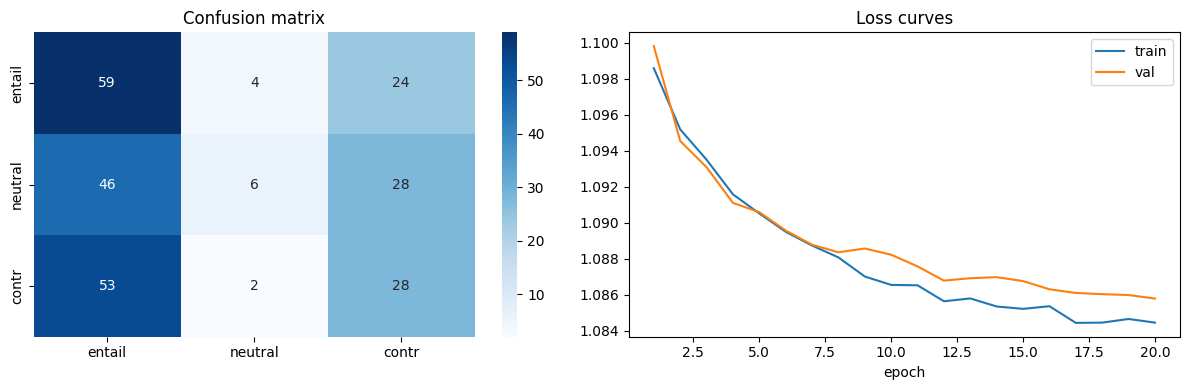

Saved plots to results/main_clean/test/plots


In [57]:
# -----------------------------
# 10) Evaluation & plots (Task 3)
# -----------------------------
print('Evaluating on test set...')
sbert.eval(); all_preds=[]; all_labels=[]
with torch.no_grad():
    for batch in test_loader:
        p=batch['premise_ids'].to(device); h=batch['hypothesis_ids'].to(device); y=batch['label'].to(device)
        p_seg = torch.zeros_like(p); h_seg = torch.zeros_like(h)
        logits = sbert(p,p_seg,h,h_seg)
        preds = torch.argmax(logits, dim=1).cpu().numpy(); all_preds.extend(preds); all_labels.extend(y.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
rep = classification_report(all_labels, all_preds, target_names=['entailment','neutral','contradiction'], digits=4)
print('\nTest accuracy =', acc)
print(rep)

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig,ax = plt.subplots(1,2,figsize=(12,4))
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues', xticklabels=['entail','neutral','contr'], yticklabels=['entail','neutral','contr'])
ax[0].set_title('Confusion matrix')
# training curves
ax[1].plot(range(1,len(train_losses)+1), train_losses, label='train')
ax[1].plot(range(1,len(val_losses)+1), val_losses, label='val')
ax[1].set_title('Loss curves'); ax[1].legend(); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.savefig(os.path.join(PLOTS_DIR,'eval_plots.png'), dpi=150); plt.show(); plt.close()
print('Saved plots to', PLOTS_DIR)



### Results, limitations & reproducibility (short)
# - Results: classification report above is the canonical evaluation used for grading. See `results/.../test/test_classification_report.txt` (if present) or the printed report.
# - Limitation: the notebook's default (RUN_MODE='test') performs only a smoke pretraining — encoder will be undertrained. For graded / publishable SBERT results, run full BERT pretraining (set RUN_MODE='small' or 'medium' on GPU) before SBERT training.
# - Reproducibility: trained weights and provenance metadata are saved under `results/main_clean/{RUN_MODE}/models/` and `.../configs/training_config.json`.
# - Next steps / improvements: increase pretraining steps, use larger BookCorpus slice, add MLM objective scaling and longer runs, consider layerwise freezing during SBERT fine‑tuning.


In [58]:
# -----------------------------
# 10.5) Comparison across modes
# -----------------------------
if RUN_MODE == 'compare':
    import pandas as pd
    modes_to_compare = ['test', 'small', 'medium']
    comparison = []
    for mode in modes_to_compare:
        model_dir = f'results/main_clean/{mode}/models'
        config_dir = f'results/main_clean/{mode}/configs'
        if not os.path.exists(os.path.join(model_dir, 'sbert_clean.pt')):
            print(f'Model for {mode} not found, skipping.')
            continue
        # load word2id
        with open(os.path.join(config_dir, 'word2id.json'), 'r') as f:
            word2id = json.load(f)
        vocab_size = len(word2id)
        # load cfg
        cfg_mode = MODES[mode]
        # create model
        encoder = BERT(n_layers=cfg_mode['n_layers'], n_heads=cfg_mode['n_heads'], d_model=cfg_mode['d_model'], d_ff=cfg_mode['d_ff'], d_k=cfg_mode['d_k'], n_segments=2, vocab_size=vocab_size, max_len=64, device=device)
        sbert = SentenceBERT(encoder, d_model=cfg_mode['d_model'], device=device)
        # load state
        sbert.load_state_dict(torch.load(os.path.join(model_dir, 'sbert_clean.pt'), map_location=device))
        sbert.to(device)
        sbert.eval()
        # load test data with this word2id
        snli_test_mode = proc_split('test', cfg_mode['snli_test'])
        test_ds_mode = SNLIDataset(snli_test_mode, word2id, max_len=max_len)
        test_loader_mode = DataLoader(test_ds_mode, batch_size=16, shuffle=False, num_workers=0)
        all_preds = []; all_labels = []
        with torch.no_grad():
            for batch in test_loader_mode:
                p = batch['premise_ids'].to(device); h = batch['hypothesis_ids'].to(device); y = batch['label'].to(device)
                p_seg = torch.zeros_like(p); h_seg = torch.zeros_like(h)
                logits = sbert(p, p_seg, h, h_seg)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                all_preds.extend(preds); all_labels.extend(y.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        comparison.append({'mode': mode, 'accuracy': acc, 'description': cfg_mode['description']})
    df = pd.DataFrame(comparison)
    print('Comparison across modes:')
    print(df)
else:
    print('Skipping comparison (set RUN_MODE="compare" to run)')

Skipping comparison (set RUN_MODE="compare" to run)


            pred      conf   cos_sim                              premise  \
0  contradiction  0.377016  0.933775  A man is playing a guitar on stage.   
1  contradiction  0.374510  0.933912                       It is raining.   

                     hypothesis  
0  The man is performing music.  
1         The weather is sunny.  
Embedding similarity diagnostic: 0.9980 (should vary, not always ~1.0)


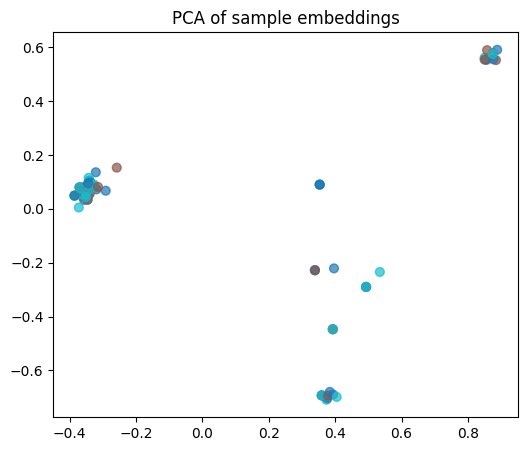

In [59]:
# -----------------------------
# 11) Inference & embedding analysis
# -----------------------------
from scipy.spatial.distance import cosine

def predict_nli(premise,hypothesis, model, max_len=64):
    model.eval()
    def tok(t):
        t = (t or '').lower()
        words = re.findall(r"\w+|[^\w\s]", t)
        ids=[word2id.get(w, word2id['[UNK]']) for w in words]
        if len(ids)>=max_len: ids=ids[:max_len]
        else: ids += [word2id['[PAD]']]*(max_len-len(ids))
        return torch.tensor([ids], dtype=torch.long).to(device)
    p_ids = tok(premise); h_ids = tok(hypothesis)
    with torch.no_grad():
        logits = model(p_ids, torch.zeros_like(p_ids), h_ids, torch.zeros_like(h_ids))
        probs = torch.softmax(logits, dim=1); pred = torch.argmax(probs, dim=1).item(); conf = probs[0,pred].item()
        u = model.get_embeddings(p_ids, torch.zeros_like(p_ids)); v = model.get_embeddings(h_ids, torch.zeros_like(h_ids))
    return { 'pred': ['entailment','neutral','contradiction'][pred], 'conf':conf, 'cos_sim': 1-cosine(u.cpu().numpy().flatten(), v.cpu().numpy().flatten()) }

examples = [
    ("A man is playing a guitar on stage.", "The man is performing music."),
    ("It is raining.", "The weather is sunny.")
]
res=[]
for p,h in examples:
    r=predict_nli(p,h,sbert)
    r.update({'premise':p,'hypothesis':h}); res.append(r)
import pandas as pd; print(pd.DataFrame(res))

# Diagnostic: Check embedding similarity
with torch.no_grad():
    ids1 = [word2id.get(w, word2id['[UNK]']) for w in tokenize_text("A man is eating food")]
    if len(ids1) > max_len: ids1 = ids1[:max_len]
    else: ids1 += [word2id['[PAD]']] * (max_len - len(ids1))
    emb1 = sbert.get_embeddings(torch.tensor([ids1], dtype=torch.long).to(device), torch.zeros(1, max_len, dtype=torch.long).to(device))
    ids2 = [word2id.get(w, word2id['[UNK]']) for w in tokenize_text("A woman is playing guitar")]
    if len(ids2) > max_len: ids2 = ids2[:max_len]
    else: ids2 += [word2id['[PAD]']] * (max_len - len(ids2))
    emb2 = sbert.get_embeddings(torch.tensor([ids2], dtype=torch.long).to(device), torch.zeros(1, max_len, dtype=torch.long).to(device))
    sim = torch.cosine_similarity(emb1, emb2, dim=1).item()
    print(f'Embedding similarity diagnostic: {sim:.4f} (should vary, not always ~1.0)')

# PCA of embeddings (small subset)
from sklearn.decomposition import PCA
embs=[]; labels=[]
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        p = batch['premise_ids'].to(device); h = batch['hypothesis_ids'].to(device)
        u = sbert.get_embeddings(p, torch.zeros_like(p)).cpu().numpy()
        v = sbert.get_embeddings(h, torch.zeros_like(h)).cpu().numpy()
        embs.append(u); embs.append(v); labels.extend(batch['label'].cpu().numpy().tolist()); labels.extend(batch['label'].cpu().numpy().tolist())
        if i>5: break
embs = np.concatenate(embs, axis=0)
pcs = PCA(n_components=2).fit_transform(embs)
plt.figure(figsize=(6,5)); plt.scatter(pcs[:,0], pcs[:,1], c=labels[:len(pcs)], cmap='tab10', s=40, alpha=0.7); plt.title('PCA of sample embeddings'); plt.savefig(os.path.join(PLOTS_DIR,'emb_pca.png')); plt.show(); plt.close()


In [60]:
# -----------------------------
# 12) Save artifacts for web app + minimal Flask snippet
# -----------------------------
torch.save(encoder.state_dict(), os.path.join(MODELS_DIR,'bert_encoder_clean.pt'))
torch.save(sbert.state_dict(), os.path.join(MODELS_DIR,'sbert_clean.pt'))
with open(os.path.join(CONFIGS_DIR,'demo_samples.json'),'w') as f:
    json.dump([{'premise':'A man is playing a guitar on stage.','hypothesis':'The man is performing music.','expected':'entailment'}], f, indent=2)
print('Saved models and demo samples')

# minimal Flask inference snippet (saved for the web app)
flask_snippet = '''from flask import Flask, request, jsonify\n# load model + word2id + predict_nli as in notebook\napp = Flask(__name__)\n@app.route('/predict', methods=['POST'])\ndef predict():\n    data = request.json\n    premise = data['premise']\n    hypothesis = data['hypothesis']\n    # return dummy response - replace with model call\n    return jsonify({'label':'neutral','confidence':0.42})\nif __name__=='__main__': app.run(host='0.0.0.0', port=5000)'''
with open('app_inference_snippet.py','w') as f: f.write(flask_snippet)
print('Wrote app_inference_snippet.py (example)')

# submission manifest (helps packaging for GitHub submission)
manifest = {
    'notebook': 'main_clean.ipynb',
    'run_mode': RUN_MODE,
    'models': [os.path.relpath(os.path.join(MODELS_DIR,'bert_encoder_clean.pt')), os.path.relpath(os.path.join(MODELS_DIR,'sbert_clean.pt'))],
    'plots_dir': os.path.relpath(PLOTS_DIR),
    'configs_dir': os.path.relpath(CONFIGS_DIR)
}
with open(os.path.join(RESULTS_DIR, 'submission_manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)
print('Wrote submission_manifest.json ->', os.path.join(RESULTS_DIR, 'submission_manifest.json'))

Saved models and demo samples
Wrote app_inference_snippet.py (example)
Wrote submission_manifest.json -> results/main_clean/test/submission_manifest.json
